## About

In this notebook we will be exploring the following [dataset](https://www.kaggle.com/datasets/mursideyarkin/mobile-games-ab-testing-cookie-cats) from kaggle.

**Context:**
This dataset includes A/B test results of Cookie Cats to examine what happens when the first gate in the game was moved from level 30 to level 40. When a player installed the game, he or she was randomly assigned to either gate_30 or gate_40.

The data we have is from 90,189 players that installed the game while the AB-test was running. 
The variables are:
- userid: A unique number that identifies each player.
- version: Whether the player was put in the control group (gate_30 - a gate at level 30) or the group with the moved gate (gate_40 - a gate at level 40).
- sum_gamerounds: the number of game rounds played by the player during the first 14 days after install.
- retention_1: Did the player come back and play 1 day after installing?
- retention_7: Did the player come back and play 7 days after installing?

When a player installed the game, he or she was randomly assigned to either.


**Goal:**
Evaluate A/B testing results and decide whether to set the gate to 30 or 40.

**Target Metric:**
0.1 * retention_1 + 0.7 * retention_7 + 0.2 * (sum_gamerounds - min)/(max - min)

As I looked at common metrics and variations used in practice, i found the: Retention-Weighted Engagement
They thereby value long term Retention and Engagment more than short them one. This totally makes sense cause in our case we want to have long term engaging users. In our case retention_1 is the short term retention, retention_7 the long term retention and sum_gamerounds the engagement.
When testing the RWE resulted in very extreme, non tangible values and I therefore came up with the Target Metric:
0.1 * retention_1 + 0.7 * retention_7 + 0.2 * (sum_gamerounds - min)/(max - min)

The 7 day rentiont is the most valuable, followed by the normalized sum of gamerounds; and the retention after 1 day also counts a little.
The resulting score ranges approximately from 0 (least desirable) to 1 (most desirable). We calculate that for each player and afterwards compare across gate_30 vs. gate_40. The gate with the higher mean score indicates the better-performing configuration.

## Load the dataset and Overview of the dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp
import scipy.stats as stats
import shutil
from itertools import combinations

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [2]:
from consts import COOKIE_CATS_DATASET

We use a copy of the dataset to leave the original one untouched.

In [3]:
shutil.copy(COOKIE_CATS_DATASET, "Datasets/cookie_cats_copy.csv")
cookie_cats_data = pd.read_csv("Datasets/cookie_cats_copy.csv")

In [4]:
cookie_cats_data.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [5]:
cookie_cats_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   userid          90189 non-null  int64 
 1   version         90189 non-null  object
 2   sum_gamerounds  90189 non-null  int64 
 3   retention_1     90189 non-null  bool  
 4   retention_7     90189 non-null  bool  
dtypes: bool(2), int64(2), object(1)
memory usage: 2.2+ MB


We can see that we have 90189 rows and 5 columns.
The datatypes are fine as well and we specifically observe the following columns: 'userid', 'version', 'sum_gamerounds', 'retention_1', 'retention_7'.

## Data Cleaning

Checking for missing values:

In [6]:
cookie_cats_data.isna().mean() * 100

userid            0.0
version           0.0
sum_gamerounds    0.0
retention_1       0.0
retention_7       0.0
dtype: float64

We see that no values are missing.

Now let's check for duplicate rows and columns:

In [7]:
print(cookie_cats_data.duplicated().any())

cookie_cats_data_t = cookie_cats_data.T
print(cookie_cats_data_t.duplicated().any())

False
False


No duplicate rows and columns detected.

## Calculations

Aggregating and preparing data as needed. Reporting key information about the A/B test, including the sample size and variant proportions.

### Key information about the A/B test:

We start with our sample size - number of users included in this test:

In [8]:
print(f"sample size: {cookie_cats_data['userid'].nunique()}")

sample size: 90189


Now we take a look at the variant proportions differentiating between the two first gates; gate 30 and 40:

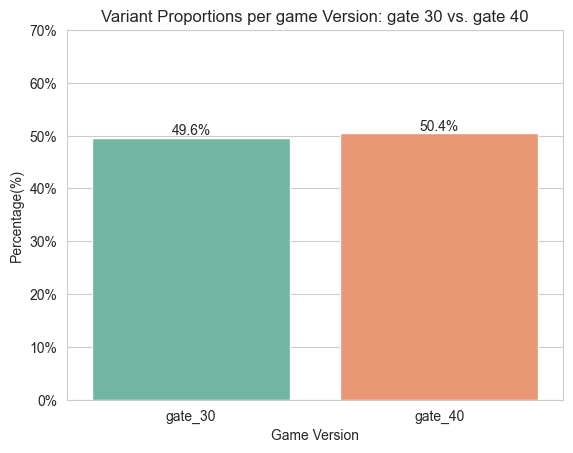

In [9]:
variant_proportions = cookie_cats_data["version"].value_counts(normalize=True)

sns.set_style("whitegrid")
colors = [sns.color_palette("Set2")[1], sns.color_palette("Set2")[0]]

ax = sns.barplot(
    x=variant_proportions.index,
    y=variant_proportions.values,
    legend=False,
    order=["gate_30", "gate_40"],
    hue=variant_proportions.index,
    palette=colors,
)
for container in ax.containers:
    ax.bar_label(
        container, labels=[f"{v*100:.1f}%" for v in container.datavalues], fontsize=10
    )
plt.title("Variant Proportions per game Version: gate 30 vs. gate 40")
plt.ylabel("Percentage(%)")
plt.xlabel("Game Version")
plt.ylim(0, 0.7)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y*100:.0f}%"))

plt.show()

We see that the dataset is quite balanced between the game versions, with variant proportions: gate 40 with 50.4% and gate 30 with 49.6%. 

Although we notice that the number of samples in each variant is not exactly the same. Some discrepancy should be expected due to randomness, but large differences, when they are not expected, are a symptom of a bug in the way units were randomized. This is known as sample ratio mismatch (SRM). Before we proceed with the analysis of the test, we test for the sample ratio mismatch using the chi-square test.

**Chi-square test:**

Nullhypothesis: The game versions have equal assignment ratios - no sample ratio mismatch (SRM) 

Alternative Hypothesis: The rate of the promotions differ - we have a SRM

Significance level: 0.05

We will now calculate the p-values.

In [10]:
counts = cookie_cats_data["version"].value_counts()
statistic, p_value = sp.stats.chisquare(f_obs=counts.values)
print(f"chi2 statistic: {statistic:.2f}")
print(f"p value: {p_value:.2f}")

chi2 statistic: 6.90
p value: 0.01


In [11]:
counts

version
gate_40    45489
gate_30    44700
Name: count, dtype: int64

We see that the p value ~ 0.01 < 0.05 (our significance level). We therefore reject our Nullhypothesis, which means that we observe SRM. 

We will now calculate the exact SRM in percentage to see whats going on and whether this statistical discrepancy is relevant in our case cause the sample size is big and chi2 is sensitive for large sample sizes, and whether we have to handle it.

In [12]:
observed = np.array([counts["gate_40"], counts["gate_30"]])
total = len(cookie_cats_data)

expected = np.array([total / 2] * 2)

srm_percent = (observed - expected) / expected * 100
print(f"gate 40 SRM: {srm_percent[0]:.2f}%")
print(f"gate 30 SRM: {srm_percent[1]:.2f}%")

gate 40 SRM: 0.87%
gate 30 SRM: -0.87%


The SRM values are +0.87 and -0.87, which means that the actual, observed number of gate 40 players is only 0.87% higher than the expected one under 50/50% split ratio, and the actual, observed number of gate 30 players is only 0.87% less than the expected one under 50/50% split ratio.

The SRM is negligible, which the original plot observation of the variant proportions also suggested. 

We will start with our aggregation.

**Aggregating and preparing data as needed:**

Now let's prepare our dataset and calculate our **target metric**:

We clip all sum_gamerounds values above the 95th percentile to reduce the impact of extreme outliers and ensure fair comparability between groups.

In [13]:
max_rounds = cookie_cats_data['sum_gamerounds'].quantile(0.95)
min_rounds = cookie_cats_data['sum_gamerounds'].min()

cookie_cats_data["Score"] = (
    0.1 * cookie_cats_data["retention_1"].astype(int)
    + 0.7 * cookie_cats_data["retention_7"].astype(int)
    + 0.2 * (cookie_cats_data["sum_gamerounds"].clip(upper=max_rounds) - min_rounds) / (max_rounds - min_rounds)
)

In [14]:
cookie_cats_data["Score"].describe()

count    90189.000000
mean         0.213234
std          0.330382
min          0.000000
25%          0.004525
50%          0.050679
75%          0.163348
max          1.000000
Name: Score, dtype: float64

In [15]:
cookie_cats_data.loc[cookie_cats_data["Score"].idxmax()]

userid               2218
version           gate_30
sum_gamerounds        305
retention_1          True
retention_7          True
Score                 1.0
Name: 14, dtype: object

Now we compare this metric **across the gates**.

In [16]:
metric_across_gates = (
    cookie_cats_data.groupby("version")["Score"]
    .describe()
    .reset_index()
)
metric_across_gates

,version,count,mean,std,min,25%,50%,75%,max
0,gate_30,44700.0,0.216486,0.332512,0.0,0.005430,0.057919,0.164253,1.0
1,gate_40,45489.0,0.210039,0.328247,0.0,0.004525,0.047059,0.161538,1.0


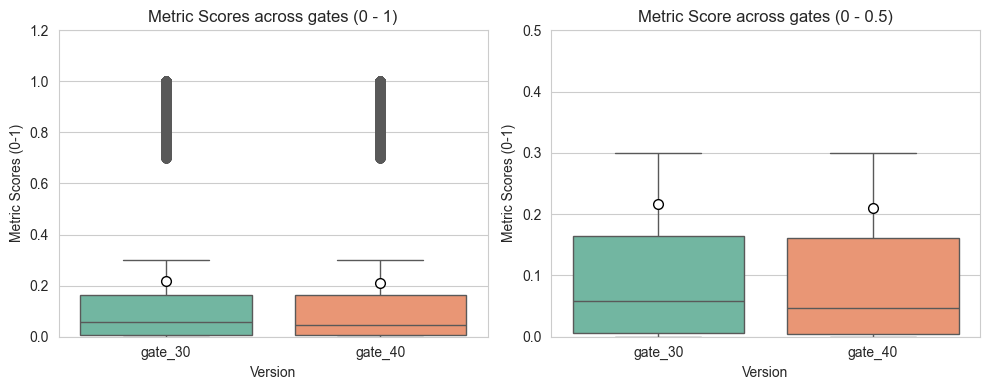

In [17]:
sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

colors = sns.color_palette("Set2", n_colors=2)

ax = axes[0]
sns.boxplot(
    data=cookie_cats_data,
    x="version",
    y="Score",
    palette=colors,
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": 7,
    },
    hue="version",
    legend=False,
    ax=ax,
)

ax.set_xlabel("Version")
ax.set_ylabel("Metric Scores (0-1)")
ax.set_title("Metric Scores across gates (0 - 1)")
ax.set_ylim(0, 1.2)

ax = axes[1]
sns.boxplot(
    data=cookie_cats_data,
    x="version",
    y="Score",
    palette=colors,
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": 7,
    },
    hue="version",
    legend=False,
    ax=ax,
)
ax.set_xlabel("Version")
ax.set_ylabel("Metric Scores (0-1)")
ax.set_title("Metric Score across gates (0 - 0.5)")
ax.set_ylim(0, 0.5)

plt.tight_layout()
plt.show()

The boxplots reveal that both gate versions exhibit a bimodal distribution, with most players scoring low (<0.3) due to poor 7-day retention, while a smaller group of engaged players achieves high scores (0.7-1.0). The upper cluster varies between 0.7-0.9 as these players all have 7-day retention (0.7 base score) but differ in 1-day retention and gameplay engagement. The zoomed view shows Gate_30 outperforming Gate_40 with a median of 0.058 vs 0.047 and means of 0.216 vs 0.210 - a difference of 0.006 points. Given the large sample size (n=90189), even this modest difference may be statistically significant, which we will test in the next section.

**Key information about the A/B test - Summary:**

- Sample Size - number of user during observed phase: 90189
- Variant Proportions: gate 40 with 50.4% and gate 30 with 49.6% - SRM after Chi2 test, but negligible cause: gate 40 SRM: 0.87%
gate, 30 SRM: -0.87%
- Aggregation and Data Preparation:
  - Target Metric: 0.1 * retention_1 + 0.7 * retention_7 + 0.2 * (sum_gamerounds - min)/(max - min)
    
    We clip all sum_gamerounds values above the 95th percentile to reduce the impact of extreme outliers and ensure fair comparability between groups.

**->** The zoomed view shows Gate_30 outperforming Gate_40 with a median of 0.058 vs 0.047 and means of 0.216 vs 0.210 - a difference of 0.006 points. Given the large sample size (n=90189), even this modest difference may be statistically significant, which we will test in the next section.

### Are the differences statistically significant?

**Conduct statistical tests.** 

We will now continue with conducting statistical tests to check whether the observed differences in performance are statistically significant. - 
First we form our groups, which are Scores by gate.

In [18]:
groups = {
    p: cookie_cats_data.loc[cookie_cats_data["version"] == p, "Score"].to_numpy()
    for p in sorted(cookie_cats_data["version"].unique())
}
X = list(groups.values())

**T-Test:**

Null Hypothesis: The difference in mean scores between gate_30 and gate_40 is zero - no difference in player engagement and retention.

Alternative Hypothesis: The mean scores differ between the two gate positions - one gate performs better or worse than the other.

Significance level: 0.05

We will now calculate the p-value to determine if the observed difference is statistically significant. We also want to quantify how much better one gate performs than the other to have a tangible, actionable result. Therefore, we compute the estimated treatment effect including its 95% confidence interval.

In [27]:
a = groups["gate_30"]
b = groups["gate_40"]

t_stat, p_val = stats.ttest_ind(a, b, equal_var=True)

estimated_tr_effect = a.mean() - b.mean()

n1, n2 = len(a), len(b)
s1, s2 = a.var(ddof=1), b.var(ddof=1)
s_p = np.sqrt(((n1 - 1) * s1 + (n2 - 1) * s2) / (n1 + n2 - 2))
se = s_p * np.sqrt(1 / n1 + 1 / n2)
df = n1 + n2 - 2
ci_low, ci_high = stats.t.interval(0.95, df, loc=estimated_tr_effect, scale=se)

results = {
    "t_stat": round(float(t_stat), 2),
    "p_value": round(float(p_val), 3),
    "estimated_tr_effect": round(float(estimated_tr_effect), 4),
    "ci_95_low": round(float(ci_low), 4),
    "ci_95_high": round(float(ci_high), 4),
}

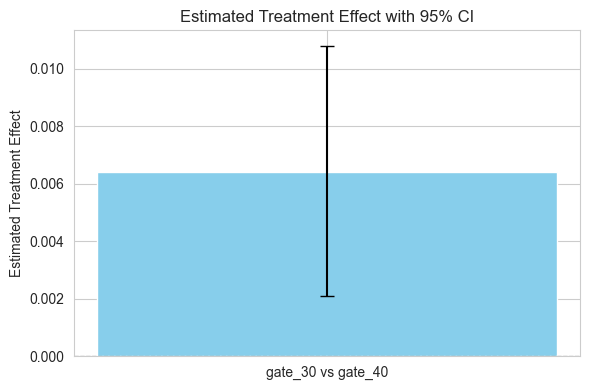

In [28]:
estimated_effect = results["estimated_tr_effect"]
ci_low = results["ci_95_low"]
ci_high = results["ci_95_high"]

plt.figure(figsize=(6, 4))
plt.bar(
    0,
    estimated_effect,
    yerr=[[estimated_effect - ci_low], [ci_high - estimated_effect]],
    capsize=5,
    color="skyblue",
)

plt.xticks([0], ["gate_30 vs gate_40"])
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.ylabel("Estimated Treatment Effect")
plt.title("Estimated Treatment Effect with 95% CI")
plt.tight_layout()
plt.show()

In [24]:
print(f"Gate 30 vs Gate 40: \n{results}")

Gate 30 vs Gate 40: 
{'t_stat': 2.93, 'p_value': 0.003, 'estimated_tr_effect': 0.0064, 'ci_95_low': 0.0021, 'ci_95_high': 0.0108}


The t-test shows that Gate_30 statistically significantly outperforms Gate_40. The p-value of 0.003 is well below the 0.05 significance level, indicating that the observed difference is unlikely due to chance. The estimated treatment effect is 0.0064 on the 0–1 target score, meaning that, on average, players in Gate_30 achieve a ~0.0064 higher score than those in Gate_40. The 95% confidence interval [0.0021, 0.0108] confirms that this difference is robust.

This brings us to the results.

## Decision

Gate 30 statistically significantly outperforms Gate 40:
- Estimated treatment effect: 0.0064
- 95% Confidence Interval: [0.0021, 0.0108]
- p value: 0.003

Interpretation: Gate_30 is statistically significant, but only slightly better. The effect is small, yet reliably detected given the large sample size.

**Final Decision:**
- Keep the first gate at level 30 (Gate_30).